# DL085 偏好学习与语言模型后训练

本Notebook使用真实Python内核顺序运行。先读lecture.md与lab.md。只验证明确限定的离线教学机制，不代表真实LLM性能。

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import experiment as exp
print("Python",sys.version.split()[0],"NumPy",np.__version__)

Python 3.12.14 NumPy 2.3.5


## 完整实验与真实输出
运行会在本目录outputs写入可复核结果。

In [2]:
result=exp.main()
print(json.dumps(result,ensure_ascii=False,indent=2))

{
  "seed": 85,
  "model": "two-candidate conditional policy; not a text-generating LLM",
  "train_pairs": 400,
  "test_pairs_per_condition": 1000,
  "results": {
    "reference": {
      "weights": [
        0.8,
        0.0
      ],
      "beta": null,
      "evaluation": {
        "id": {
          "sampled_correctness": 0.6899744811276124,
          "greedy_correctness": 1.0,
          "annotator_agreement": 0.871,
          "mean_reference_kl": 0.0,
          "mean_verbose_probability": 0.6762963184864245
        },
        "balanced": {
          "sampled_correctness": 0.6899744811276124,
          "greedy_correctness": 1.0,
          "annotator_agreement": 0.899,
          "mean_reference_kl": 0.0,
          "mean_verbose_probability": 0.4920210717926402
        },
        "conflict": {
          "sampled_correctness": 0.6899744811276124,
          "greedy_correctness": 1.0,
          "annotator_agreement": 0.884,
          "mean_reference_kl": 0.0,
          "mean_verbose_proba

## 标签与相关性

In [3]:
X,y=exp.fixture()
print("train shape",X.shape,"same feature sign",np.mean(X[:,0]==X[:,1]))

train shape (400, 2) same feature sign 0.955


## 参考起点与DPO

In [4]:
reference=np.array([.8,0.])
print("initial DPO loss",exp.objective(reference,X,y)[0],"log2",np.log(2))
np.testing.assert_allclose(exp.objective(reference,X,y)[0],np.log(2))

initial DPO loss 0.6931471805599452 log2 0.6931471805599453


## 独立冲突测试

In [5]:
Xc,yc=exp.fixture(1000,0,853)
w,_=exp.train(X,(X[:,1]>0).astype(int))
print("biased weights",w)
print("conflict evaluation",exp.evaluate(w,Xc,yc))

biased weights [3.89867177 5.73423583]
conflict evaluation {'sampled_correctness': 0.13757676877978883, 'greedy_correctness': 0.0, 'annotator_agreement': 0.116, 'mean_reference_kl': 0.660499137622593, 'mean_verbose_probability': 0.8624232312202108}


## 全部单元测试
同时检查边界与失败路径，不只观察损失下降。

In [6]:
import unittest
suite=unittest.defaultTestLoader.discover(str(Path.cwd()),pattern="test_experiment.py")
check=unittest.TextTestRunner(verbosity=2).run(suite)
if not check.wasSuccessful(): raise RuntimeError("tests failed")

test_beta (test_experiment.Tests.test_beta) ... 

ok


test_conflict (test_experiment.Tests.test_conflict) ... 

ok


test_dpo_improves (test_experiment.Tests.test_dpo_improves) ... 

...

test_sft_improves (test_experiment.Tests.test_sft_improves) ... 

ok


test_train_repeat (test_experiment.Tests.test_train_repeat) ... 

ok


----------------------------------------------------------------------
Ran 13 tests in 0.078s

OK


## 从输出重建原创图
图的数值来自本次实验，不是示意数字。

figure count 4


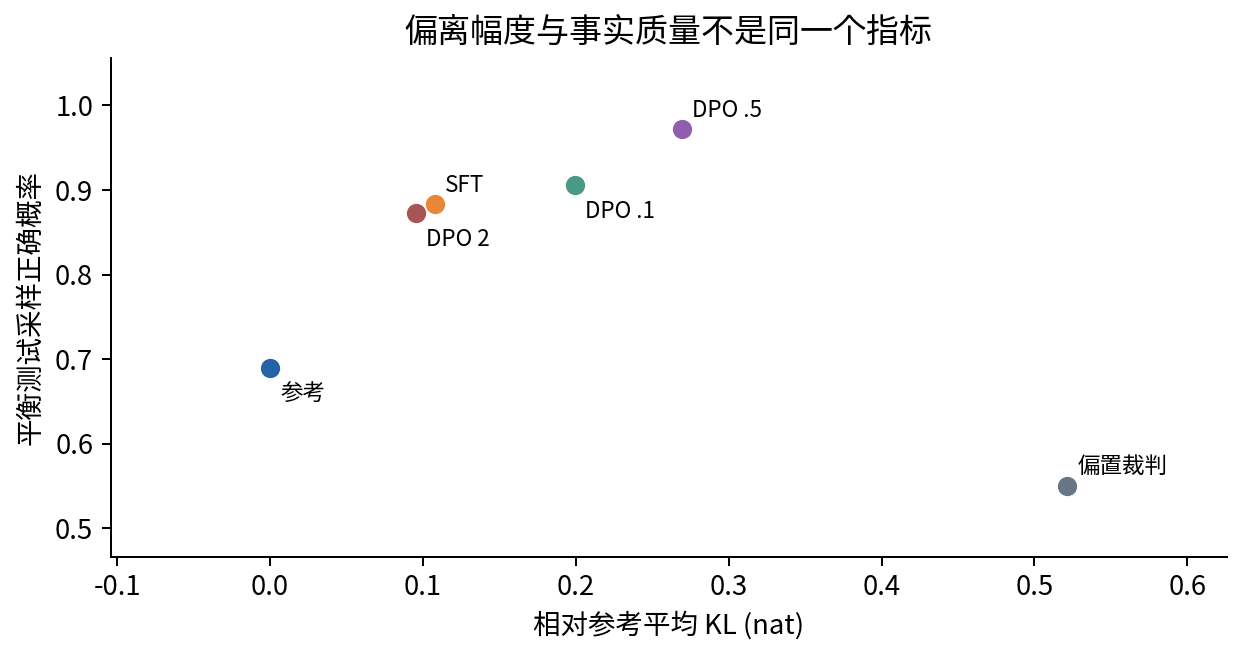

In [7]:
import make_figures
make_figures.main()
from IPython.display import display, Image
figures=sorted(Path("figures").glob("*.png"))
print("figure count",len(figures))
display(Image(filename=str(figures[-1])))

## 研究记录
写下一个受支持结论、一个失败/限制，以及下一步需要的新证据。参考答案在answers.md，不能用参考结论替代你自己的检查。

In [8]:
print("Output files:",sorted(p.name for p in Path("outputs").iterdir() if p.is_file()))

Output files: ['environment.json', 'history.json', 'metrics.json', 'notebook-execution.json', 'replay-comparison.json', 'weights.npz']
